# 🚌 Campus Transport Price Prediction System
### Live Model Training & Demonstration Notebook

**Nnamdi Azikiwe University (UNIZIK), Awka Campus — Final Year Project**

This notebook reproduces the *entire* machine learning pipeline from `train_model.py`,
broken into individual cells so it can be run **live**, step by step.
Every output, table and chart below is generated fresh from the **real** dataset when you run the cells.


## Step 0 — Check Your Environment

This cell checks that every required package is installed **in the same Python environment Jupyter Lab is using.**

In [1]:
import importlib
import sys

print(f"Python executable in use: {sys.executable}")
print(f"Python version: {sys.version.split()[0]}")
print()

required_packages = ['pandas', 'numpy', 'sklearn', 'matplotlib', 'seaborn', 'joblib']
all_ok = True

for pkg in required_packages:
    try:
        mod = importlib.import_module(pkg)
        version = getattr(mod, '__version__', 'unknown version')
        print(f"✅ {pkg:<12} — installed ({version})")
    except ImportError:
        print(f"❌ {pkg:<12} — NOT FOUND. Run: pip install {pkg}")
        all_ok = False

print()
if all_ok:
    print("🎉 Everything is installed correctly. You're ready to continue.")
else:
    print("⚠️  Please install the missing package(s) above, then restart the kernel and re-run this cell.")

Python executable in use: c:\program files\python39\python.exe
Python version: 3.9.6

✅ pandas       — installed (2.3.3)
✅ numpy        — installed (2.0.2)
✅ sklearn      — installed (1.6.1)
✅ matplotlib   — installed (3.9.4)
✅ seaborn      — installed (0.13.2)
✅ joblib       — installed (1.5.3)

🎉 Everything is installed correctly. You're ready to continue.


## Step 1 — Import Libraries

These are the same libraries installed on this system from the cmd: `pandas` for tables, `numpy` for math,
`scikit-learn` for the machine learning models, and `matplotlib`/`seaborn` for charts. The `%matplotlib inline`
line tells Jupyter to display charts directly inside the notebook, right under the cell that created them.

In [2]:
%matplotlib inline

import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42
print('Libraries imported successfully.')

Libraries imported successfully.


## Step 2 — Load the Dataset

This cell first **checks that the dataset file can actually be found** before trying to load it — if a
warning appears below, it usually means Jupyter Lab was started from the wrong folder.

In [3]:
DATA_PATH = os.path.join('data', 'campus_transport_dataset.csv')

if not os.path.exists(DATA_PATH):
    print('⚠️  Could not find the dataset at:', DATA_PATH)
    print('Current working directory is:', os.getcwd())
    print("Make sure Jupyter Lab was started from INSIDE the 'campus_transport_project' folder,")
    print("and that this notebook sits in that same folder (next to app.py and train_model.py).")
else:
    print('✅ Dataset found. Loading...')
    df = pd.read_csv(DATA_PATH)
    print(f'Loaded {len(df)} rows and {len(df.columns)} columns.')

df.head(10)

✅ Dataset found. Loading...
Loaded 254 rows and 7 columns.


,Year,Fuel_Price_NGN_per_Litre,Transport_Price_NGN,Fee_Bus_17Seater_NGN,Fee_ShuttleBus_7Seater_NGN,Fee_Tricycle_4Seater_NGN,Festive_Period
0,Jan-2016,87.57,15,100,30,15,0
1,Jan-2016,86.87,15,100,30,15,0
2,Feb-2016,87.75,15,100,30,15,0
3,Feb-2016,87.41,15,100,30,15,0
4,Mar-2016,86.15,25,100,30,15,1
5,Mar-2016,87.55,30,100,30,15,1
6,Apr-2016,87.60,15,100,30,15,0
7,Apr-2016,86.22,15,100,30,15,0
8,May-2016,144.83,20,150,40,20,0
9,May-2016,144.55,20,150,40,20,0


## Step 3 — Explore and Clean the Data

Basic checks: data types, missing values, and duplicate rows. This is the *Data Understanding* and
*Data Preparation* phase from my Chapter 3's CRISP-DM methodology, made visible.

In [4]:
print('--- Column data types ---')
print(df.dtypes)
print()
print('--- Missing values per column ---')
print(df.isnull().sum())
print()
print(f'--- Duplicate rows: {df.duplicated().sum()} ---')

--- Column data types ---
Year                           object
Fuel_Price_NGN_per_Litre      float64
Transport_Price_NGN             int64
Fee_Bus_17Seater_NGN            int64
Fee_ShuttleBus_7Seater_NGN      int64
Fee_Tricycle_4Seater_NGN        int64
Festive_Period                  int64
dtype: object

--- Missing values per column ---
Year                          0
Fuel_Price_NGN_per_Litre      0
Transport_Price_NGN           0
Fee_Bus_17Seater_NGN          0
Fee_ShuttleBus_7Seater_NGN    0
Fee_Tricycle_4Seater_NGN      0
Festive_Period                0
dtype: int64

--- Duplicate rows: 0 ---


In [5]:
# Clean the data: drop exact duplicates and rows missing key columns
df = df.drop_duplicates()
required_cols = ['Year', 'Fuel_Price_NGN_per_Litre', 'Transport_Price_NGN', 'Festive_Period']
df = df.dropna(subset=required_cols)

# Parse 'Jan-2016' style text into a real date, and sort chronologically
df['Period'] = pd.to_datetime(df['Year'], format='%b-%Y')
df = df.sort_values('Period').reset_index(drop=True)

# Make sure numeric columns have the right type
df['Fuel_Price_NGN_per_Litre'] = df['Fuel_Price_NGN_per_Litre'].astype(float)
df['Transport_Price_NGN'] = df['Transport_Price_NGN'].astype(float)
df['Festive_Period'] = df['Festive_Period'].astype(int)

print(f'Dataset ready: {len(df)} clean rows, spanning {df["Period"].min().date()} to {df["Period"].max().date()}.')
df.describe()

Dataset ready: 254 clean rows, spanning 2016-01-01 to 2026-07-01.


,Fuel_Price_NGN_per_Litre,Transport_Price_NGN,Fee_Bus_17Seater_NGN,Fee_ShuttleBus_7Seater_NGN,Fee_Tricycle_4Seater_NGN,Festive_Period,Period
count,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000,254
mean,387.411811,101.535433,357.480315,95.275591,47.637795,0.086614,2021-04-01 06:25:30.708661504
min,86.150000,15.000000,100.000000,30.000000,15.000000,0.000000,2016-01-01 00:00:00
25%,144.862500,20.000000,150.000000,40.000000,20.000000,0.000000,2018-08-08 18:00:00
50%,165.220000,50.000000,250.000000,70.000000,35.000000,0.000000,2021-04-01 00:00:00
75%,663.427500,172.500000,550.000000,150.000000,75.000000,0.000000,2023-11-23 12:00:00
max,1213.840000,525.000000,800.000000,200.000000,100.000000,1.000000,2026-07-01 00:00:00
std,374.359617,107.395527,241.997512,61.442821,30.721410,0.281824,NaN


## Step 4 — Quick Visual Exploration

Before training anything, it's good practice to *look* at the relationship between the predictors and the
target. This chart shows Fuel Price against Transport Price, coloured by Festive Period — where
festive months (orange) are sitting noticeably higher than the general trend.

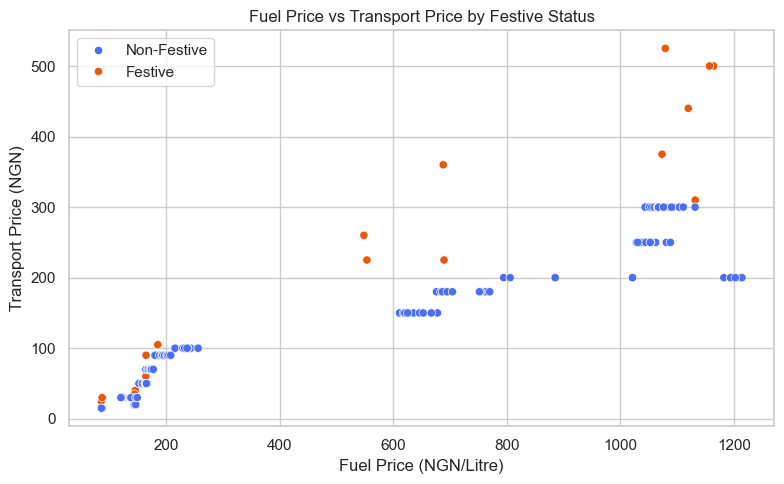

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Fuel_Price_NGN_per_Litre',
    y='Transport_Price_NGN',
    hue=df['Festive_Period'].map({0: 'Non-Festive', 1: 'Festive'}),
    palette={'Non-Festive': '#4C6EF5', 'Festive': '#E8590C'},
    ax=ax,
)
ax.set_title('Fuel Price vs Transport Price by Festive Status')
ax.set_xlabel('Fuel Price (NGN/Litre)')
ax.set_ylabel('Transport Price (NGN)')
ax.legend(title='')
plt.tight_layout()
plt.show()

## Step 5 — Select Features (Predictors) and Target

As specified in my system architecture (Chapter 3, Fig. 3.8), exactly **two predictors** are used:
Fuel Price and Festive Period. The target — the value we're trying to predict — is the general
Transport Price.

In [7]:
feature_cols = ['Fuel_Price_NGN_per_Litre', 'Festive_Period']
target_col = 'Transport_Price_NGN'

X = df[feature_cols]
y = df[target_col]

print('Features (X):', feature_cols)
print('Target (y):  ', target_col)
X.head()

Features (X): ['Fuel_Price_NGN_per_Litre', 'Festive_Period']
Target (y):   Transport_Price_NGN


,Fuel_Price_NGN_per_Litre,Festive_Period
0,87.57,0
1,86.87,0
2,87.75,0
3,87.41,0
4,86.15,1


## Step 6 — Split Into Training and Testing Sets

80% of the rows are used to *train* the models; the remaining 20% are held back and only used afterwards to
*test* how well each model generalises to data it has never seen. `random_state=42` makes this split reproducible —
running this cell again will always produce the exact same split.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Training rows: {len(X_train)}')
print(f'Testing rows:  {len(X_test)}')

Training rows: 203
Testing rows:  51


## Step 7 — Train Model 1: Linear Regression (Baseline)

Wrapped in a scikit-learn `Pipeline` together with a `StandardScaler`, so scaling and prediction always happen
together as one step.

In [9]:
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression()),
])

linear_pipeline.fit(X_train, y_train)
y_pred_linear = linear_pipeline.predict(X_test)

mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print('Linear Regression trained.')
print(f'  MAE  = NGN {mae_linear:,.2f}')
print(f'  MSE  = {mse_linear:,.2f}')
print(f'  RMSE = NGN {rmse_linear:,.2f}')
print(f'  R2   = {r2_linear:.4f}')

Linear Regression trained.
  MAE  = NGN 23.38
  MSE  = 1,585.32
  RMSE = NGN 39.82
  R2   = 0.8882


## Step 8 — Train Model 2: Random Forest Regressor (Ensemble)

300 decision trees, each trained on a random sample of the training data, averaged together.

In [10]:
forest_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE)),
])

forest_pipeline.fit(X_train, y_train)
y_pred_forest = forest_pipeline.predict(X_test)

mae_forest = mean_absolute_error(y_test, y_pred_forest)
mse_forest = mean_squared_error(y_test, y_pred_forest)
rmse_forest = np.sqrt(mse_forest)
r2_forest = r2_score(y_test, y_pred_forest)

print('Random Forest Regressor trained.')
print(f'  MAE  = NGN {mae_forest:,.2f}')
print(f'  MSE  = {mse_forest:,.2f}')
print(f'  RMSE = NGN {rmse_forest:,.2f}')
print(f'  R2   = {r2_forest:.4f}')

Random Forest Regressor trained.
  MAE  = NGN 9.91
  MSE  = 719.32
  RMSE = NGN 26.82
  R2   = 0.9493


## Step 9 — Compare the Two Models

Side by side, lower MAE/MSE/RMSE is better, and higher R² is better.

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE (NGN)': [round(mae_linear, 2), round(mae_forest, 2)],
    'MSE': [round(mse_linear, 2), round(mse_forest, 2)],
    'RMSE (NGN)': [round(rmse_linear, 2), round(rmse_forest, 2)],
    'R2 Score': [round(r2_linear, 4), round(r2_forest, 4)],
}).set_index('Model')

results

,MAE (NGN),MSE,RMSE (NGN),R2 Score
Model,,,,
Linear Regression,23.38,1585.32,39.82,0.8882
Random Forest Regressor,9.91,719.32,26.82,0.9493


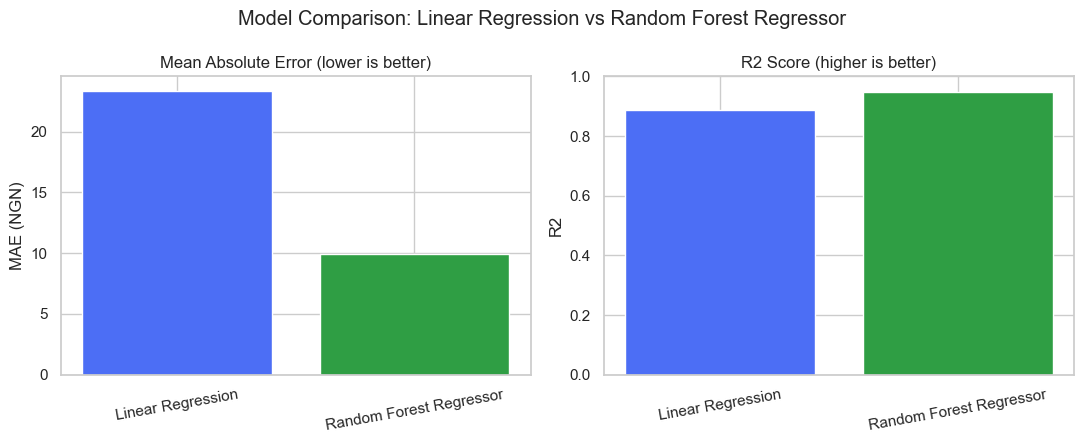

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = ['#4C6EF5', '#2F9E44']

axes[0].bar(results.index, results['MAE (NGN)'], color=colors)
axes[0].set_title('Mean Absolute Error (lower is better)')
axes[0].set_ylabel('MAE (NGN)')

axes[1].bar(results.index, results['R2 Score'], color=colors)
axes[1].set_title('R2 Score (higher is better)')
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1)

for ax in axes:
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('Model Comparison: Linear Regression vs Random Forest Regressor')
plt.tight_layout()
plt.show()

## Step 10 — Select and Save the Best Model

The model with the lowest MAE is automatically selected and saved to `model/best_model.pkl` — the exact file
the Streamlit app loads when it starts. Running this cell keeps that file in sync with this notebook run.

In [13]:
pipelines = {
    'Linear Regression': linear_pipeline,
    'Random Forest Regressor': forest_pipeline,
}
mae_scores = {
    'Linear Regression': mae_linear,
    'Random Forest Regressor': mae_forest,
}

best_name = min(mae_scores, key=mae_scores.get)
best_pipeline = pipelines[best_name]

os.makedirs('model', exist_ok=True)
joblib.dump(best_pipeline, os.path.join('model', 'best_model.pkl'))

print(f'🏆 Best model: {best_name}')
print(f'   (MAE = NGN {mae_scores[best_name]:,.2f})')
print('Saved to model/best_model.pkl')

🏆 Best model: Random Forest Regressor
   (MAE = NGN 9.91)
Saved to model/best_model.pkl


## Step 11 — Actual vs Predicted Fare (Best Model)

Every point represents one test-set row. Points sitting exactly on the dashed diagonal line are perfect
predictions; the closer the cloud of points hugs that line, the more accurate the model.

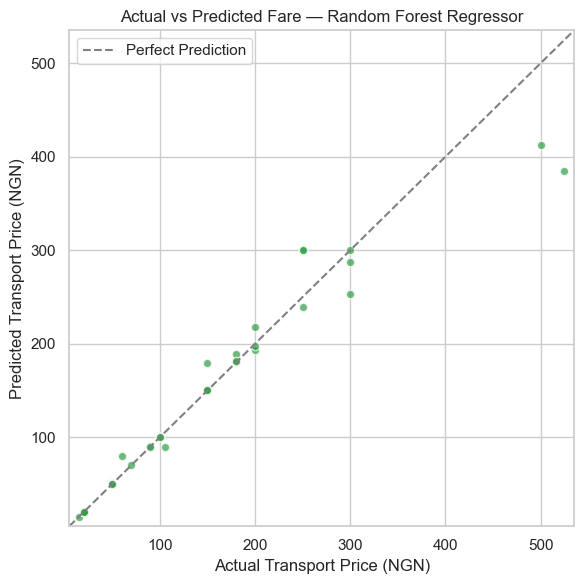

In [14]:
y_pred_best = best_pipeline.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred_best, alpha=0.7, color='#2F9E44', edgecolor='white')
lims = [min(y_test.min(), y_pred_best.min()) - 10, max(y_test.max(), y_pred_best.max()) + 10]
ax.plot(lims, lims, '--', color='gray', label='Perfect Prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual Transport Price (NGN)')
ax.set_ylabel('Predicted Transport Price (NGN)')
ax.set_title(f'Actual vs Predicted Fare — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

## Step 12 — Historical Fare Trend

The full picture: how transport price has tracked fuel price from 2016 to 2026, with festive months marked.

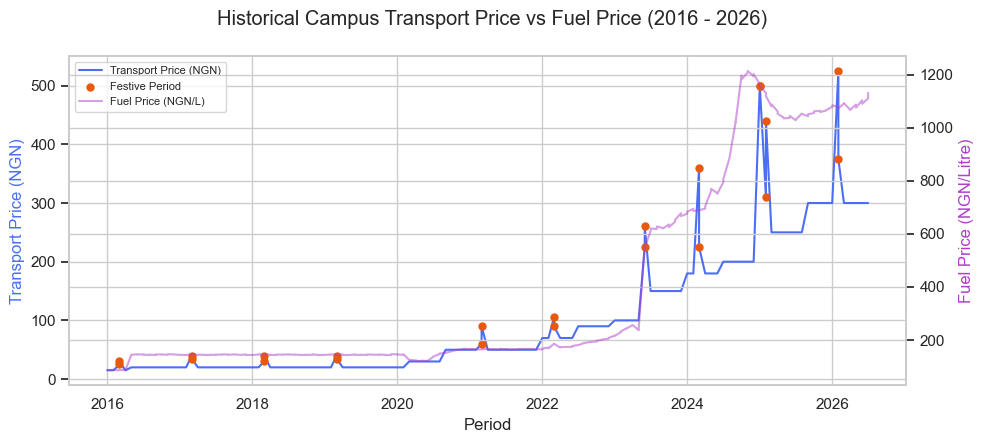

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(df['Period'], df['Transport_Price_NGN'], color='#4C6EF5', label='Transport Price (NGN)')
festive_pts = df[df['Festive_Period'] == 1]
ax1.scatter(festive_pts['Period'], festive_pts['Transport_Price_NGN'], color='#E8590C', zorder=5, label='Festive Period', s=25)
ax1.set_ylabel('Transport Price (NGN)', color='#4C6EF5')
ax1.set_xlabel('Period')

ax2 = ax1.twinx()
ax2.plot(df['Period'], df['Fuel_Price_NGN_per_Litre'], color='#AE3EC9', alpha=0.5, label='Fuel Price (NGN/L)')
ax2.set_ylabel('Fuel Price (NGN/Litre)', color='#AE3EC9')

fig.suptitle('Historical Campus Transport Price vs Fuel Price (2016 - 2026)')
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Step 13 — 🎯 Live Prediction Demo

This is the cell to run to make a live prediction. Changing the two values below to any fuel price
and festive status, and re-running the cell, updates the prediction instantly — proving the trained model
actually works, using real code.

In [16]:
# ✏️  CHANGE THESE TWO VALUES AND RE-RUN THIS CELL
test_fuel_price = 950.00     # NGN per litre
test_festive_period = 0      # 0 = No, 1 = Yes

input_df = pd.DataFrame({
    'Fuel_Price_NGN_per_Litre': [test_fuel_price],
    'Festive_Period': [test_festive_period],
})
prediction = best_pipeline.predict(input_df)[0]

festive_label = 'Yes (Festive Period)' if test_festive_period == 1 else 'No (Regular Period)'
print('=' * 50)
print(f'  Model used        : {best_name}')
print(f'  Fuel Price entered : NGN {test_fuel_price:,.2f} / Litre')
print(f'  Festive Period      : {festive_label}')
print(f'  PREDICTED FARE      : NGN {prediction:,.2f}')
print('=' * 50)

  Model used        : Random Forest Regressor
  Fuel Price entered : NGN 950.00 / Litre
  Festive Period      : No (Regular Period)
  PREDICTED FARE      : NGN 206.42


## Step 14 (Optional) — Launch the Full Web App From This Notebook

Everything above proves the *model* works. This cell launches the actual **Streamlit web application** —
the polished, finished product — directly from Jupyter, without needing to open a separate terminal.
It will open automatically in a new browser tab at `http://localhost:8501`.

⚠️ It starts a live web server that keeps running until it is stopped using the cell below.

In [17]:
import subprocess, sys, time, webbrowser

streamlit_process = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'app.py', '--server.headless', 'true'],
)

print('Starting the Streamlit app... please wait a few seconds.')
time.sleep(5)
webbrowser.open('http://localhost:8501')
print('If a browser tab did not open automatically, visit: http://localhost:8501')

Starting the Streamlit app... please wait a few seconds.
If a browser tab did not open automatically, visit: http://localhost:8501


**After demonstrating the app**, the cell below is run to shut the web server down cleanly.

In [ ]:
streamlit_process.terminate()
print('Streamlit app stopped.')

## ✅ Summary

This notebook has, from a completely fresh run:

1. Loaded and cleaned the real 254-row historical dataset
2. Visually explored the relationship between fuel price, festive period and transport price
3. Trained **two** supervised regression models — Linear Regression and Random Forest Regressor
4. Evaluated both using MAE, MSE, RMSE and R² on a held-out test set
5. Automatically selected and saved the better-performing model
6. Demonstrated a live, editable prediction using the trained model
7. Launched the deployed Streamlit web application itself

Everything above was generated live from the dataset and code in this project folder — nothing was hard-coded
or pre-computed ahead of time. Thank you for your time. 